In [1]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm import tqdm
from funcs import *
from Lfuncs import *

In [2]:
df = load_filtered_fits("/Users/calvinsridhara/Documents/GitHub/M33_Analysis/Tables/m33_vels_stars_inc22B_donedupes.fits")
report_sel_flag_combinations(df)
df = remove_high_vcorr_stars(df)

Number of stars for each SEL flag combination:
RGB_SEL: 2277
AGB_SEL: 595
OHB_SEL: 443
RHB_SEL: 596
YMS_SEL: 308
OHB_SEL, WCN_SEL: 44
AGB_SEL, CBN_SEL: 144
RHB_SEL, WCN_SEL: 475
CBN_SEL, RHB_SEL: 10
RGB_SEL, WCN_SEL: 57
AGB_SEL, WCN_SEL: 58
CBN_SEL, RGB_SEL: 21
WCN_SEL, YMS_SEL: 4
None: 20
WCN_SEL: 1
Stars with VCORR_STAT > 1000:
         RA_DEG    DEC_DEG     VCORR_STAT
889   23.428667  30.342472  221215.885079
2448  23.458708  30.796500  767133.498926
3327  23.821542  31.219528  648930.752058
4386  22.986750  31.478861   20315.068865


In [3]:
df = classify_age_groups(df) #Classiy Stars By age group

Number of stars in each age group:
age_group
old             2276
young           1984
int              769
unclassified      20
Name: count, dtype: int64


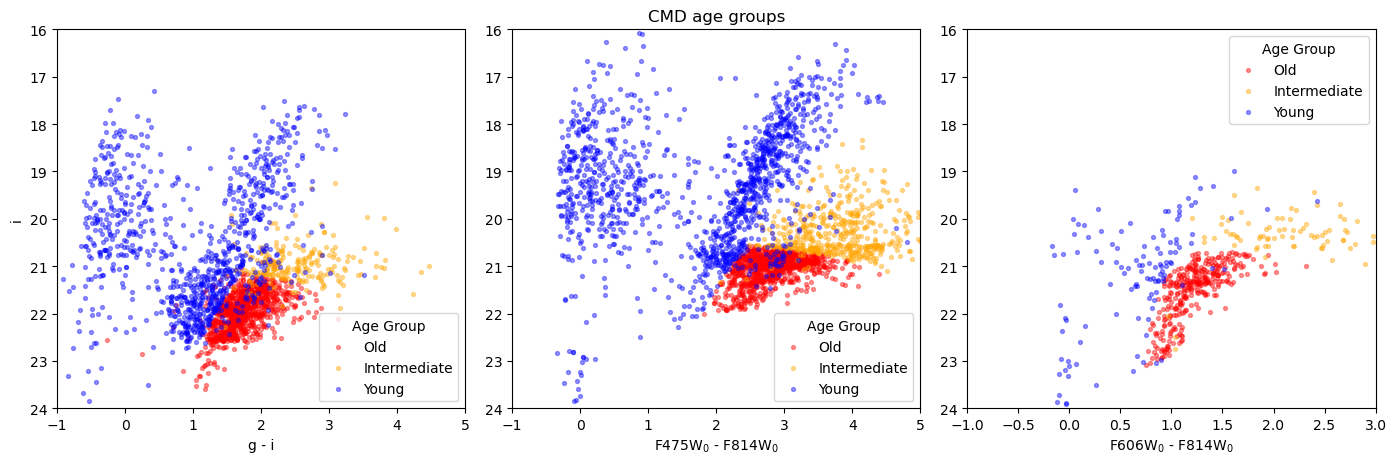

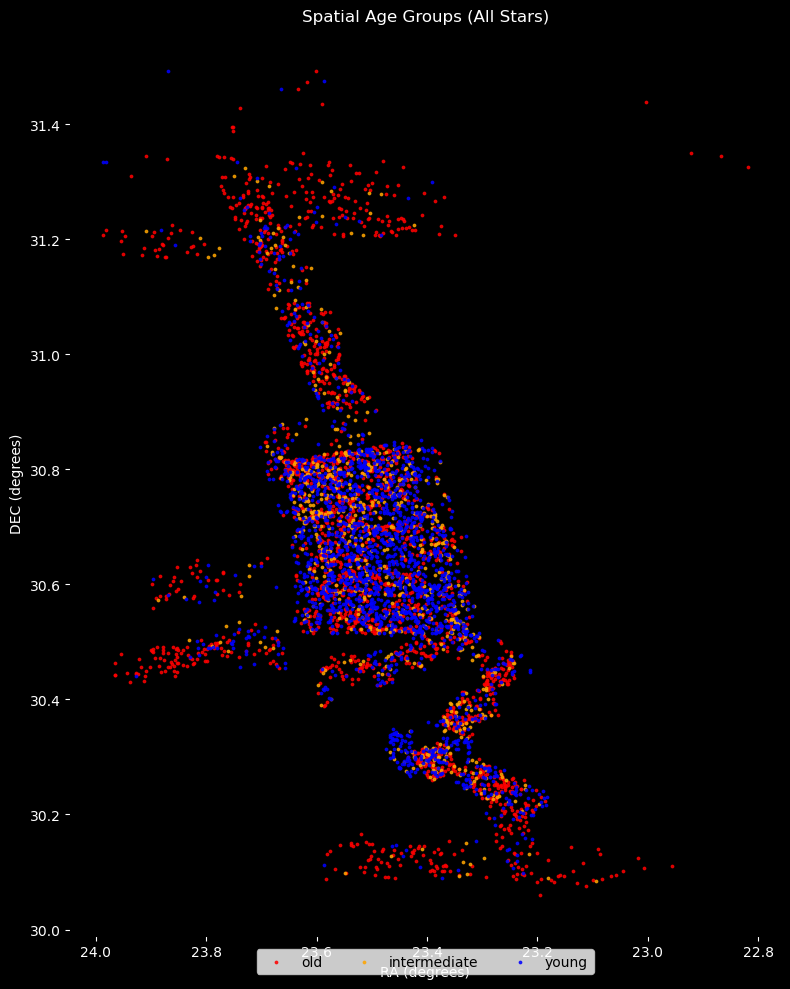

In [4]:
plot_cmd_panels(df) # Plot Color-MAgnitude Diagram
plot_spatial_age_groups(df) # Plot RA-DEC Plot

Deprojecting: 100%|████████████████████████| 5049/5049 [00:05<00:00, 976.37it/s]


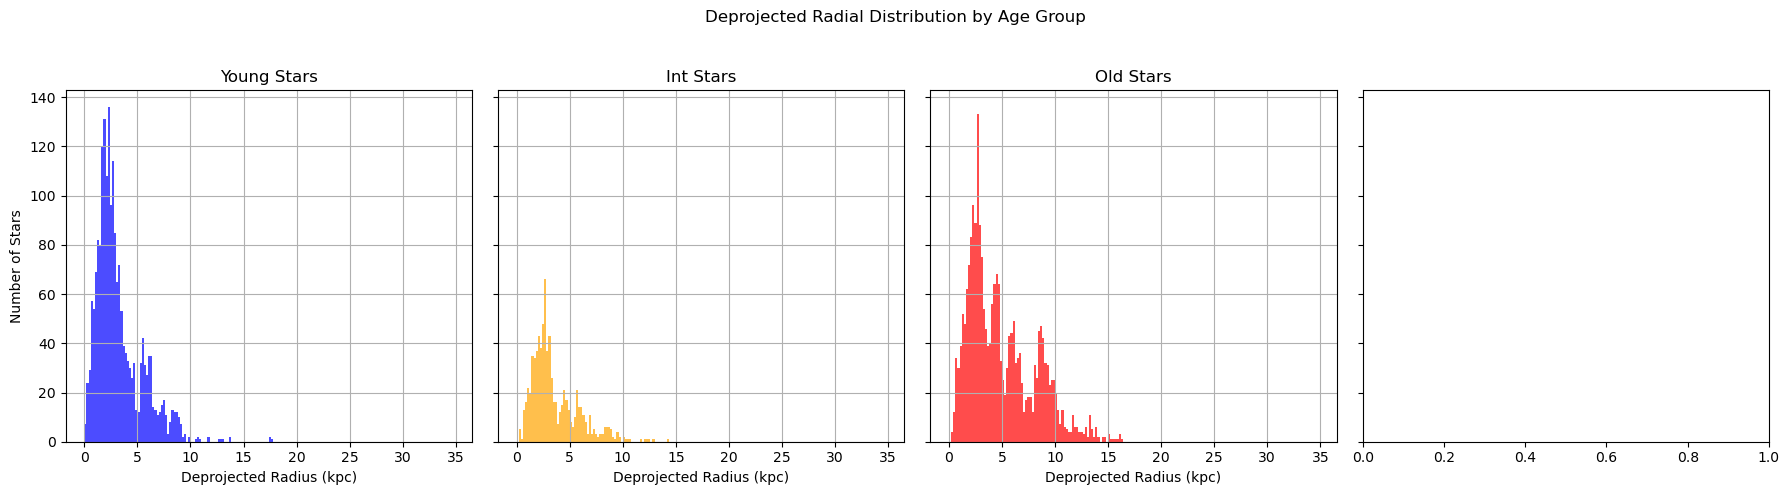

In [5]:
df = compute_deprojected_radius_tilted_ring(df) # Find Deprojected radius of a star from the center of M33
plot_radial_distribution_by_age(df) # Plot each by age

df_radial = assign_radial_thirds_equal_count(df) # Assign radial thirds
radial_summaries = generate_radial_third_agegroup_dfs(df_radial) # Give Velo
#plot_all_voffset_histograms(radial_summaries) # Plot V-offset



Matching doubles (young base): 100%|██████| 1984/1984 [00:01<00:00, 1035.83it/s]


Matched young–old pairs found: 1355


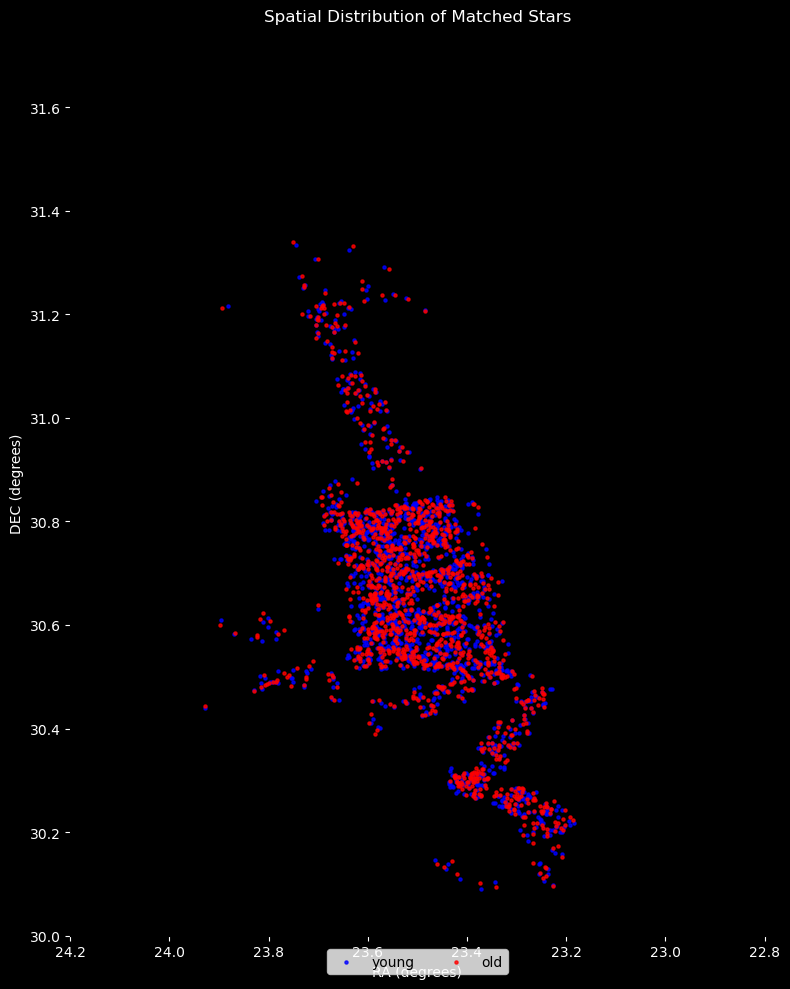

Matching triplets (young base): 100%|██████| 1984/1984 [00:02<00:00, 856.07it/s]


Matched triplets found: 698


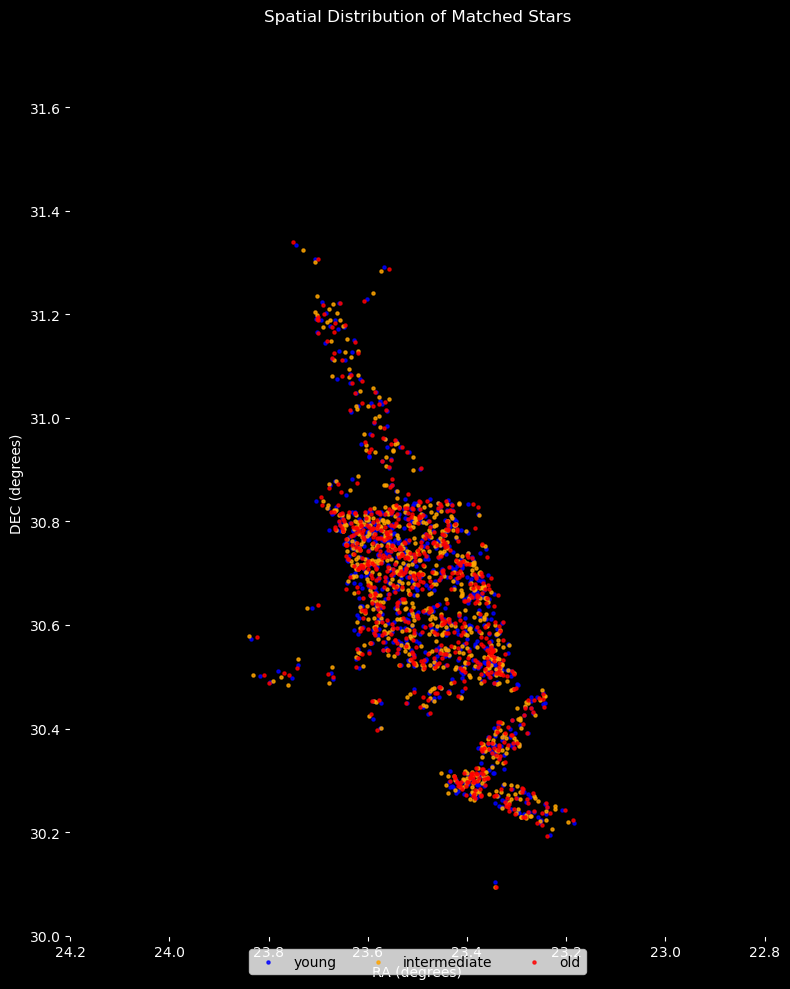

In [6]:
double_df = match_doubles(df) #Match Doubles
plot_spatial(double_df) #Plot Doubles
triplet_df = match_triplets(df)              # Match triplets
plot_spatial(triplet_df)            # Plot them

In [7]:
triplet_summary = generate_summary_with_model_vlos(triplet_df)
double_summary = generate_summary_with_model_vlos(double_df)

triplet_summary = pd.DataFrame(triplet_summary)
double_summary = pd.DataFrame(double_summary)

#print(triplet_summary.head())
#print(double_summary.head())
#plot_voffset_hist_young(triplet_summary)
#plot_voffset_hist_intermediate(triplet_summary)
#plot_voffset_hist_old(triplet_summary)
#plot_voffset_hist_young(double_summary)
#plot_voffset_hist_old(double_summary)

In [8]:
run_population_fits_full(double_summary, triplet_summary)


=== Fitting young population ===
  log(Z): -6518.89 ± 0.11
     disklag: 0.94 [+0.01, -0.01]
     disksig: 20.83 [+0.67, -0.67]
       fhalo: 0.10 [+0.01, -0.01]
     halocen: -175.56 [+85.38, -84.83]
     halosig: 98.89 [+0.82, -1.66]

=== Fitting old population ===
  log(Z): -7029.39 ± 0.09
     disklag: 0.87 [+0.02, -0.02]
     disksig: 27.78 [+1.19, -1.14]
       fhalo: 0.23 [+0.03, -0.03]
     halocen: -173.76 [+83.82, -84.70]
     halosig: 79.36 [+4.20, -3.73]

=== Fitting young population ===
  log(Z): -6509.30 ± 0.11
     disklag: 0.94 [+0.01, -0.01]
     disksig: 20.45 [+0.66, -0.63]
       fhalo: 0.11 [+0.01, -0.01]
     halocen: -139.53 [+8.97, -8.69]
     halosig: 98.35 [+1.20, -2.40]

=== Fitting old population ===
  log(Z): -7029.52 ± 0.10
     disklag: 0.87 [+0.02, -0.02]
     disksig: 27.39 [+1.13, -1.05]
       fhalo: 0.24 [+0.02, -0.02]
     halocen: -172.67 [+4.83, -4.95]
     halosig: 78.56 [+4.01, -3.59]

=== Fitting young population ===
  log(Z): -3408.37 ± 0.10


,run_type,population,optflags,halo_rotation,nstars,logZ,disklag,disklag_err_minus,disklag_err_plus,disksig,...,disksig_err_plus,fhalo,fhalo_err_minus,fhalo_err_plus,halocen,halocen_err_minus,halocen_err_plus,halosig,halosig_err_minus,halosig_err_plus
0,Doublet,young,TTTF,Fixed,1355,-6518.888640,0.939956,0.011815,0.011591,20.833400,...,0.674899,0.100291,0.013396,0.014567,-175.555390,84.832693,85.378620,98.893806,1.662941,0.819259
1,Doublet,old,TTTF,Fixed,1355,-7029.385689,0.870488,0.019144,0.019081,27.780355,...,1.190313,0.228613,0.027460,0.028734,-173.761470,84.695410,83.824073,79.363459,3.734901,4.201011
2,Doublet,young,TTFF,Fixed,1355,-6509.302858,0.938378,0.011617,0.011979,20.452409,...,0.663619,0.107471,0.012810,0.014051,-139.533402,8.687192,8.969346,98.346071,2.398202,1.201252
3,Doublet,old,TTFF,Fixed,1355,-7029.520329,0.872193,0.019076,0.018894,27.391048,...,1.126220,0.242378,0.024354,0.024202,-172.673640,4.946608,4.834534,78.563000,3.585752,4.007140
4,Triplet,young,TTTF,Fixed,698,-3408.369003,0.938856,0.016524,0.016961,22.496701,...,0.885779,0.075322,0.014327,0.017093,-175.063507,83.592078,84.840508,99.270084,1.138341,0.545130
5,Triplet,int,TTTF,Fixed,698,-3355.600396,0.912237,0.018023,0.017976,23.681932,...,0.867067,0.086638,0.016154,0.020883,-174.661494,84.693654,85.980065,36.108612,5.380507,7.795844
6,Triplet,old,TTTF,Fixed,698,-3620.117514,0.906150,0.034067,0.033064,29.356213,...,3.065933,0.260358,0.088953,0.100803,-173.384991,86.174500,85.624966,56.653254,10.213342,5.298696
7,Triplet,young,TTFF,Fixed,698,-3398.149787,0.933983,0.016947,0.017025,22.027657,...,0.856249,0.085161,0.014879,0.017154,-104.729414,14.850128,16.085310,99.109246,1.351824,0.657520
8,Triplet,int,TTFF,Fixed,698,-3356.786562,0.923901,0.017858,0.018229,22.537954,...,0.879273,0.137336,0.021876,0.022670,-165.261173,6.350991,6.293221,47.180743,4.269550,4.874805
9,Triplet,old,TTFF,Fixed,698,-3621.385122,0.915095,0.028725,0.029288,27.938192,...,1.682749,0.300744,0.034470,0.037050,-174.091391,5.088611,5.163712,59.774969,3.455590,3.902409
